## Khai báo thư viện ảnh

In [ ]:
import cv2
import matplotlib.pyplot as hung


## Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu

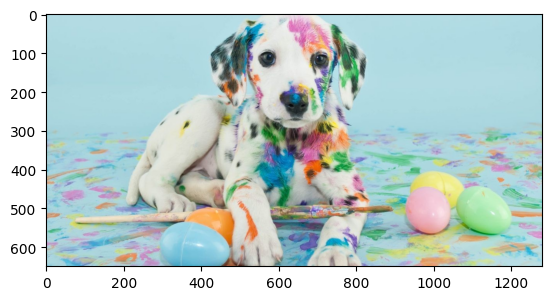

In [38]:
img = cv2.imread('dog.jpg')
img = img[:,:,::-1]
hung.imshow(img)


1. Thực hành xử lý ảnh trong miền tần số: 
- Fast Fourier Transform (FFT) algorithm để phát hiện ảnh mờ.
+ Để đọc ảnh và hiển thị ảnh, ta dùng matplotlib 


In [39]:
import numpy as np
import cv2
from matplotlib import pyplot as hung


In [40]:
img = cv2.imread('puppy_ex.png',0)
img_float32 = np.float32(img)


In [41]:
dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)


In [42]:
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

### 2. Sử dụng đoạn code sau cho DFT, trình bày ý nghĩa của từng dòng lệnh. 

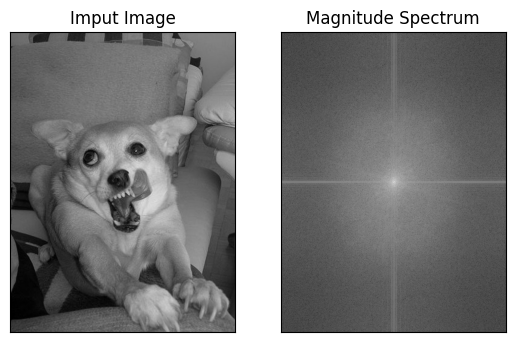

In [43]:
hung.subplot(121), hung.imshow(img, cmap = 'gray')
hung.title('Imput Image'), hung.xticks([]), hung.yticks([])
hung.subplot(122), hung.imshow(magnitude_spectrum, cmap = 'gray')
hung.title('Magnitude Spectrum'), hung.xticks([]), hung.yticks([])
hung.show()


### 3.Sử dụng Fast Fourier Transform (FFT) Magnitude algorithm để phát hiện ảnh mờ

In [44]:
import matplotlib.pyplot as hung
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

image = gravel()
wimage = image * window('hann', image.shape)  # window image to improve FFT
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))


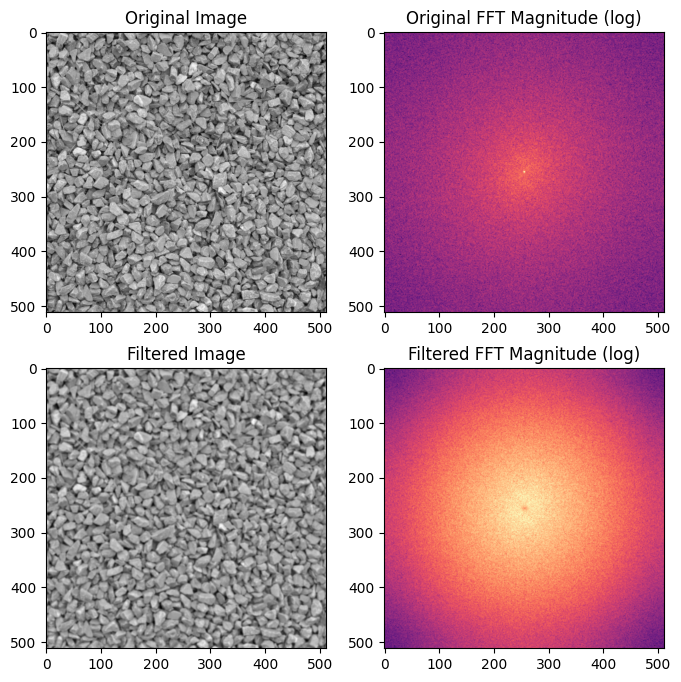

In [45]:
fig, ax = hung.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')
hung.show()


## Thực hành Harris Corner Detection 

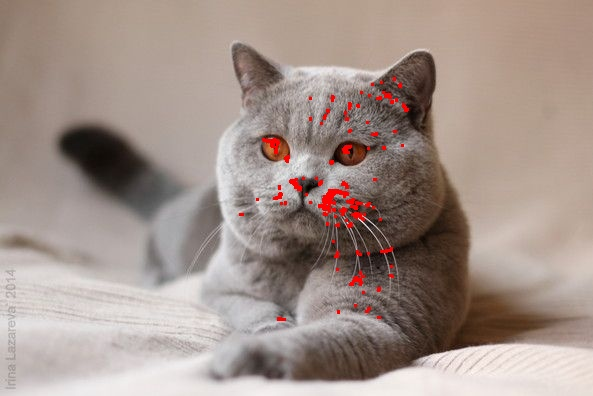

In [46]:
import cv2
import numpy as np
from IPython.display import Image

def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):
    img = cv2.imread(image_path)

    if img is None:
        print("Không đọc được ảnh:", image_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    dst = cv2.cornerHarris(gray, blockSize, ksize, k)

    # làm rõ corner
    dst = cv2.dilate(dst, None)

    # đánh dấu corner
    img[dst > threshold * dst.max()] = [0, 0, 255]

    cv2.imwrite('example.jpg', img)

    return 'example.jpg'


out_path = detect_corner('cat.jpg', blockSize=2, ksize=5, k=0.04, threshold=0.005)

if out_path:
    display(Image(out_path))

# Thực hành Harris Corner Detection 

In [47]:
import numpy as np
import cv2
from matplotlib import pyplot as hung


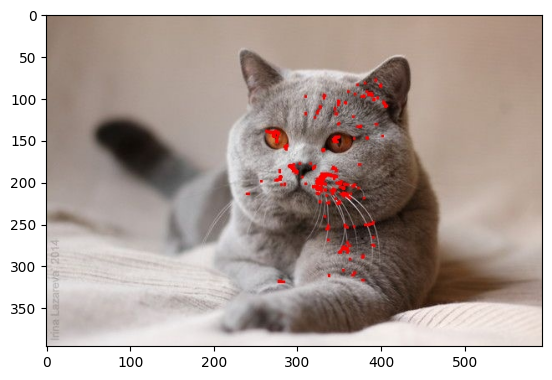

In [48]:
img = cv2.imread('example.jpg')
hung.imshow(img[:,:,::-1])


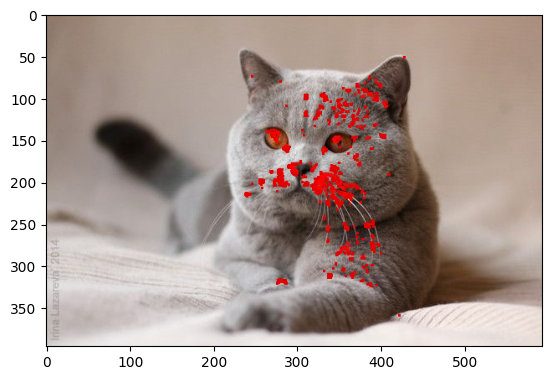

In [49]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)
dst = cv2.dilate(dst,None)
img[dst>0.01*dst.max()] = [0,0,225]
hung.imshow(img[:,:,::-1])


### Band-pass filtering by Difference of Gaussians

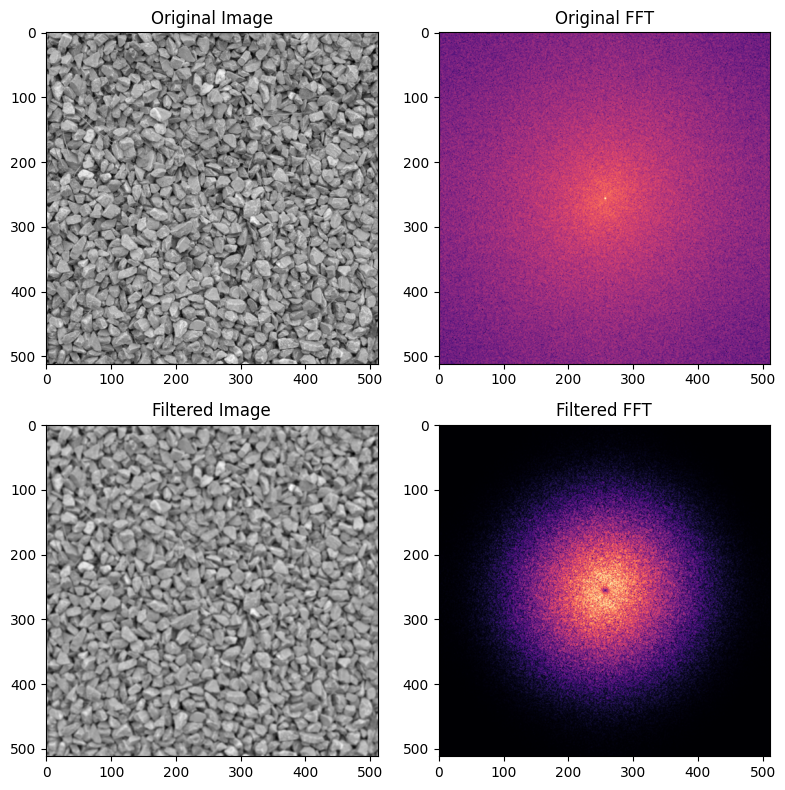

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians
from scipy.fft import fftn, fftshift
from scipy.signal.windows import hann

image = gravel()
# tạo window
win = hann(image.shape[0])[:, None] * hann(image.shape[1])[None, :]
wimage = image * win
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * win
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))
# Hiển thị kết quả
fig, ax = plt.subplots(2,2, figsize=(8,8))
ax[0,0].imshow(image, cmap='gray')
ax[0,0].set_title("Original Image")
ax[0,1].imshow(np.log(im_f_mag + 1), cmap='magma')
ax[0,1].set_title("Original FFT")
ax[1,0].imshow(filtered_image, cmap='gray')
ax[1,0].set_title("Filtered Image")
ax[1,1].imshow(np.log(fim_f_mag + 1), cmap='magma')
ax[1,1].set_title("Filtered FFT")
plt.tight_layout()
plt.show()